<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_055_ice_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 55/365 — ICE Plots
## What if the same feature affects different people differently?

Yesterday we explored **Partial Dependence Plots (PDPs)**.

PDP answers:

> On average, how does the model's prediction change as one feature changes?

But averages can hide individual behaviour.

Today we look at:

**ICE — Individual Conditional Expectation**

An ICE plot draws one response curve per observation.

That lets us see whether the same feature affects different rows in similar or very different ways.


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load the real Diabetes dataset


In [2]:
data=load_diabetes(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)

print("Dataset shape:",X.shape)
display(X.head())


Dataset shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Train a Random Forest regressor


In [3]:
model=RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)

pred=model.predict(X_test)

rmse=mean_squared_error(y_test,pred)**0.5
r2=r2_score(y_test,pred)

print("Test RMSE:",round(rmse,2))
print("Test R²:",round(r2,3))


Test RMSE: 53.93
Test R²: 0.474


## 3. Yesterday's view: PDP

We inspect the feature:

`bmi`

PDP gives one average model-response curve.


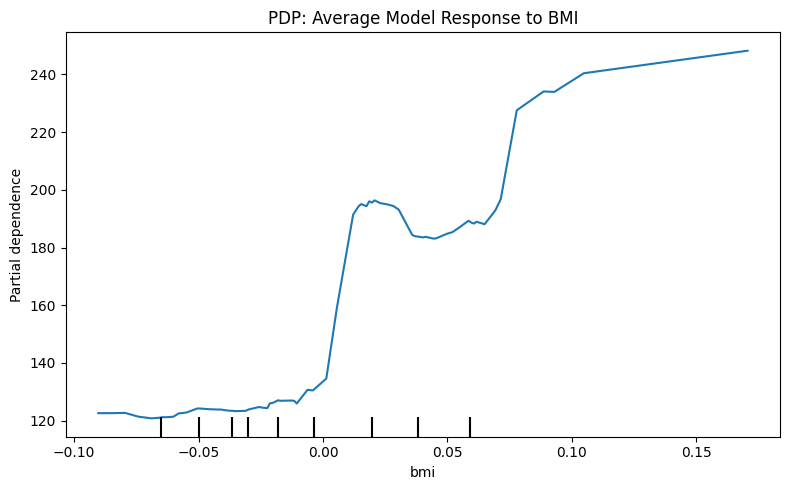

In [4]:
fig,ax=plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=["bmi"],
    kind="average",
    ax=ax
)

plt.title("PDP: Average Model Response to BMI")
plt.tight_layout()
plt.show()


## 4. ICE curves

Each line now represents one observation.

We sample a subset so the chart stays readable.


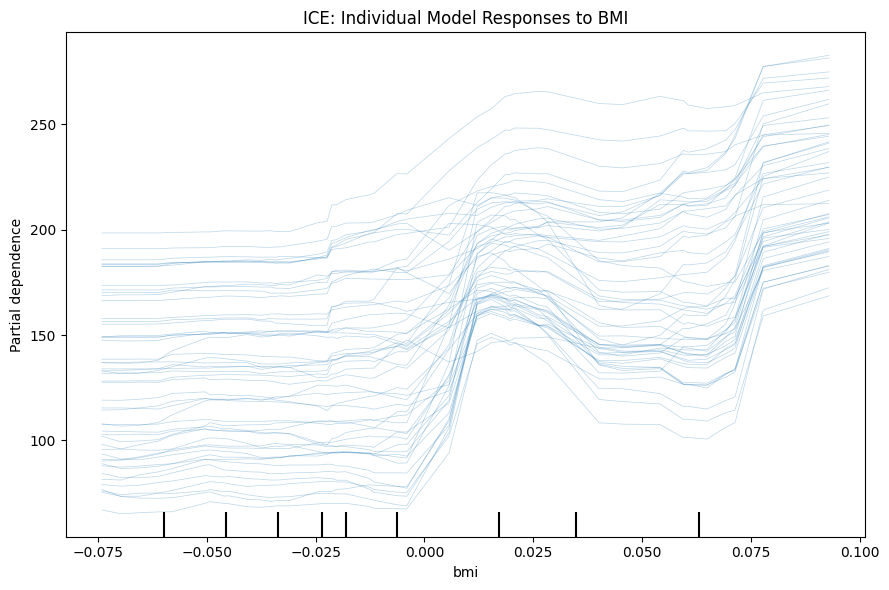

In [5]:
sample=X_test.sample(
    min(50,len(X_test)),
    random_state=42
)

fig,ax=plt.subplots(figsize=(9,6))

PartialDependenceDisplay.from_estimator(
    model,
    sample,
    features=["bmi"],
    kind="individual",
    ax=ax
)

plt.title("ICE: Individual Model Responses to BMI")
plt.tight_layout()
plt.show()


## 5. PDP + ICE together

This combines the average curve with the individual curves.


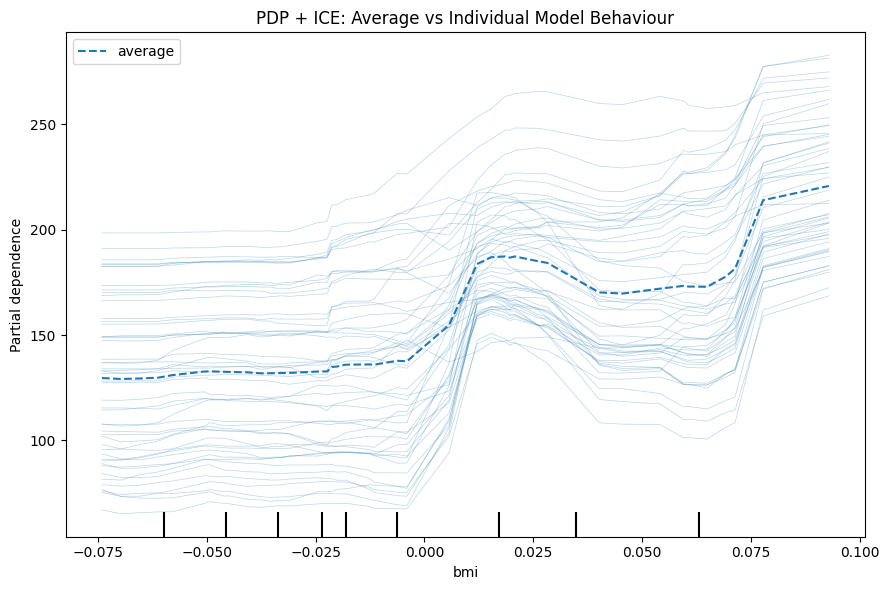

In [6]:
fig,ax=plt.subplots(figsize=(9,6))

PartialDependenceDisplay.from_estimator(
    model,
    sample,
    features=["bmi"],
    kind="both",
    ax=ax
)

plt.title("PDP + ICE: Average vs Individual Model Behaviour")
plt.tight_layout()
plt.show()


## 6. How to interpret ICE

If most curves have a similar shape:

> the model responds to the feature similarly across observations.

If curves differ substantially:

> the feature's effect may depend on other features.

That can reveal **heterogeneity** and possible feature interactions.


## Enterprise intuition

Imagine a churn model using:

`Days Since Last Login`

The PDP may show:

> churn risk rises as inactivity increases.

But ICE may reveal:

- new customers show a sharp rise after 10 inactive days
- long-term customers change only slightly
- premium customers follow a different pattern

The average PDP can hide these differences.

ICE exposes them.


## Another enterprise example

Suppose a fraud model uses:

`Transaction Amount`

PDP may suggest risk generally increases with amount.

ICE could reveal that:

- high-value established customers are less sensitive
- new accounts show a sharp increase in predicted risk
- some segments behave differently

That tells us the model may have learned interactions between transaction amount and other features.


## PDP vs ICE

**PDP:** What is the model's average response to this feature?

**ICE:** Does the model respond to this feature the same way for every observation?

ICE shows what the average may hide.


## Important limitation

Like PDP, ICE changes one feature while keeping others fixed.

With strongly correlated features, that can create unrealistic combinations.

So ICE explains model behaviour, not real-world causality.


## What does this teach?

- PDP gives an average model response.
- ICE gives one response curve per observation.
- Similar curves suggest more consistent model behaviour.
- Diverging curves can reveal heterogeneity and possible interactions.
- Averages can hide important subgroups.
- ICE explains the model, not causality.

> **PDP tells us what happens on average. ICE shows us who may behave differently from that average.**


## References

- https://scikit-learn.org/stable/modules/partial_dependence.html
- https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html
- https://doi.org/10.1080/10618600.2014.907095
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
